In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../week-1/retail_sales_cleaned.csv")

# Professional Seaborn theme
sns.set_theme(style="whitegrid", context="notebook")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 30000
Columns: 9


In [16]:
monthly_sales = (
    df.groupby(["YEAR", "MONTH"])["RETAIL SALES"]
    .sum()
    .reset_index()
)

monthly_sales["PERIOD"] = (
    monthly_sales["YEAR"].astype(str)
    + "-"
    + monthly_sales["MONTH"].astype(str).str.zfill(2)
)

monthly_sales.head()

,YEAR,MONTH,RETAIL SALES,PERIOD
0,2020,1,74318.77,2020-01
1,2020,3,34523.90,2020-03
2,2020,7,94538.96,2020-07
3,2020,9,4805.31,2020-09


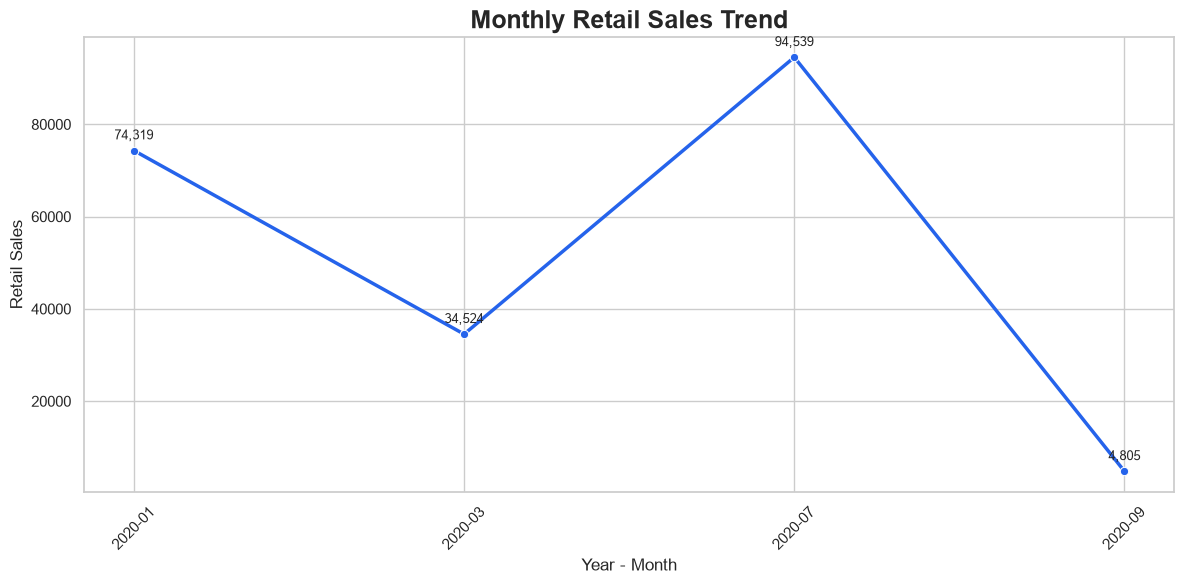

In [17]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_sales,
    x="PERIOD",
    y="RETAIL SALES",
    marker="o",
    linewidth=2.5,
    color="#2563EB"
)

plt.title(
    "Monthly Retail Sales Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year - Month", fontsize=12)
plt.ylabel("Retail Sales", fontsize=12)

plt.xticks(rotation=45)

# Data callouts
for x, y in zip(monthly_sales["PERIOD"], monthly_sales["RETAIL SALES"]):
    ax.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "monthly_retail_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

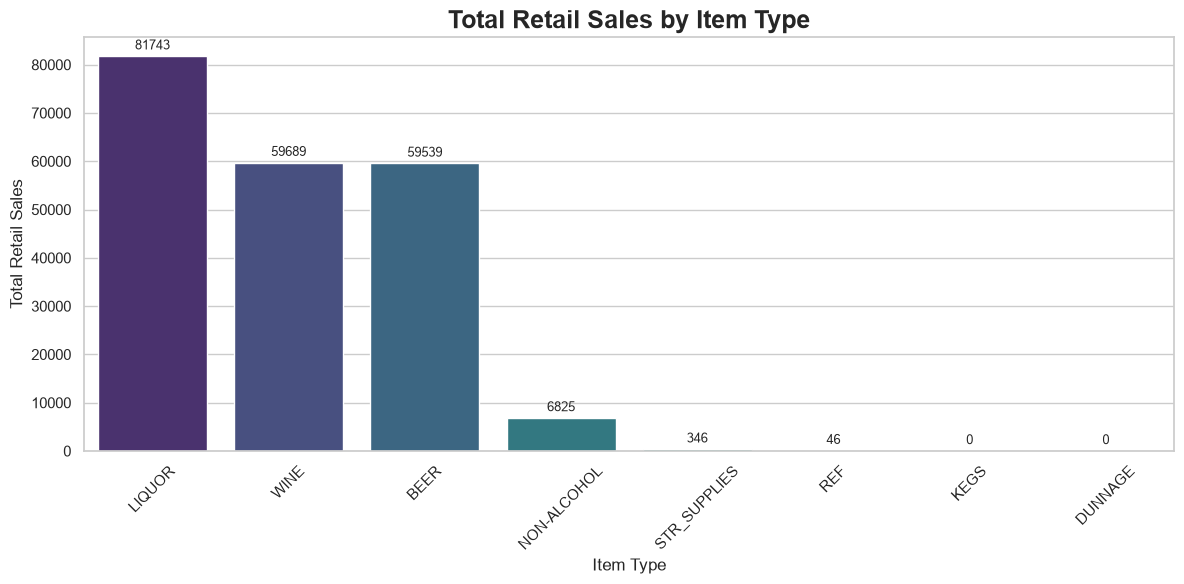

In [18]:
sales_by_item = (
    df.groupby("ITEM TYPE")["RETAIL SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=sales_by_item,
    x="ITEM TYPE",
    y="RETAIL SALES",
    hue="ITEM TYPE",
    palette="viridis",
    legend=False
)

plt.title(
    "Total Retail Sales by Item Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Item Type", fontsize=12)
plt.ylabel("Total Retail Sales", fontsize=12)

plt.xticks(rotation=45)

# Data callouts
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "retail_sales_by_item_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

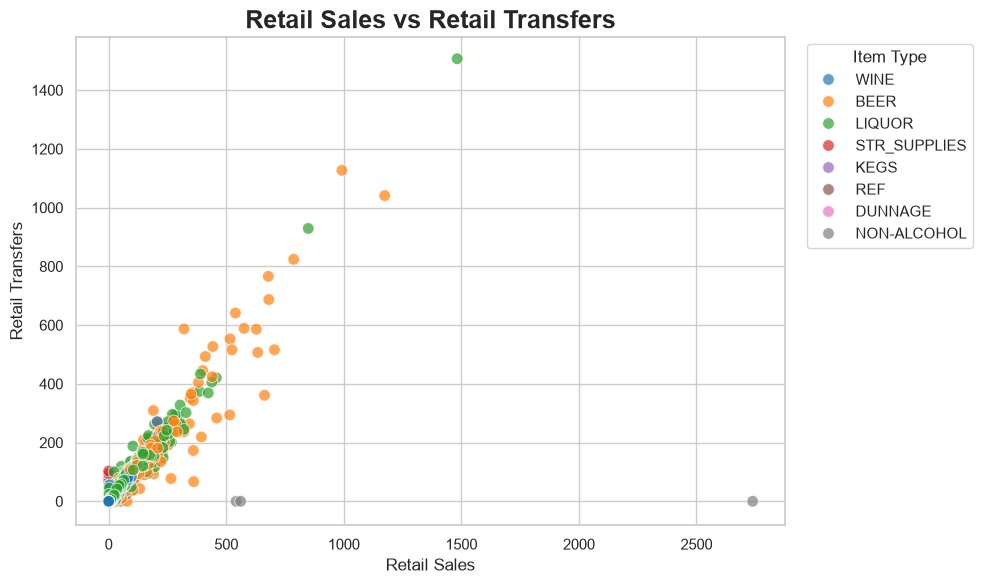

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="RETAIL SALES",
    y="RETAIL TRANSFERS",
    hue="ITEM TYPE",
    palette="tab10",
    alpha=0.7,
    s=70
)

plt.title(
    "Retail Sales vs Retail Transfers",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Retail Sales", fontsize=12)
plt.ylabel("Retail Transfers", fontsize=12)

plt.legend(
    title="Item Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "retail_sales_vs_transfers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

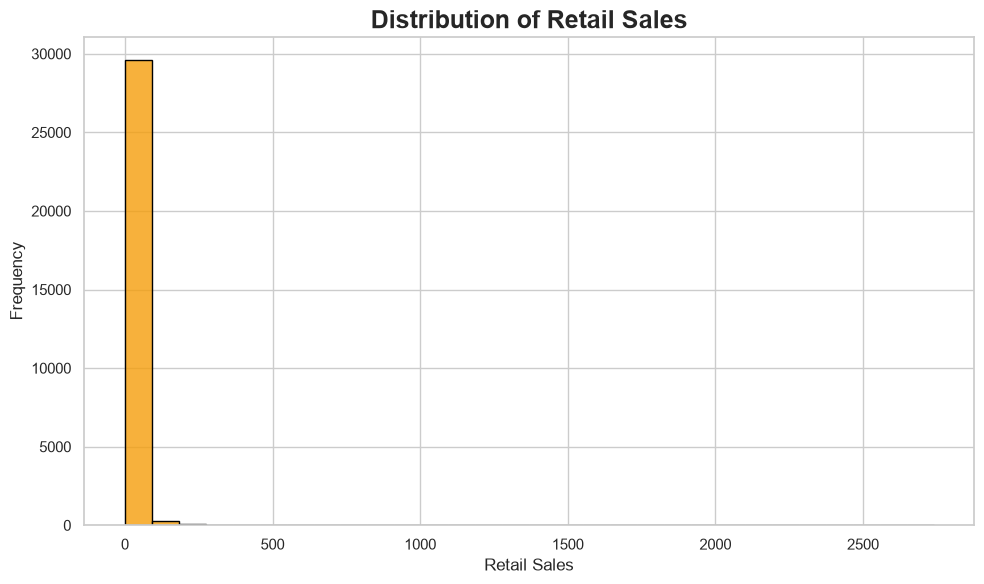

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="RETAIL SALES",
    bins=30,
    color="#F59E0B",
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribution of Retail Sales",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Retail Sales", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()

plt.savefig(
    "retail_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

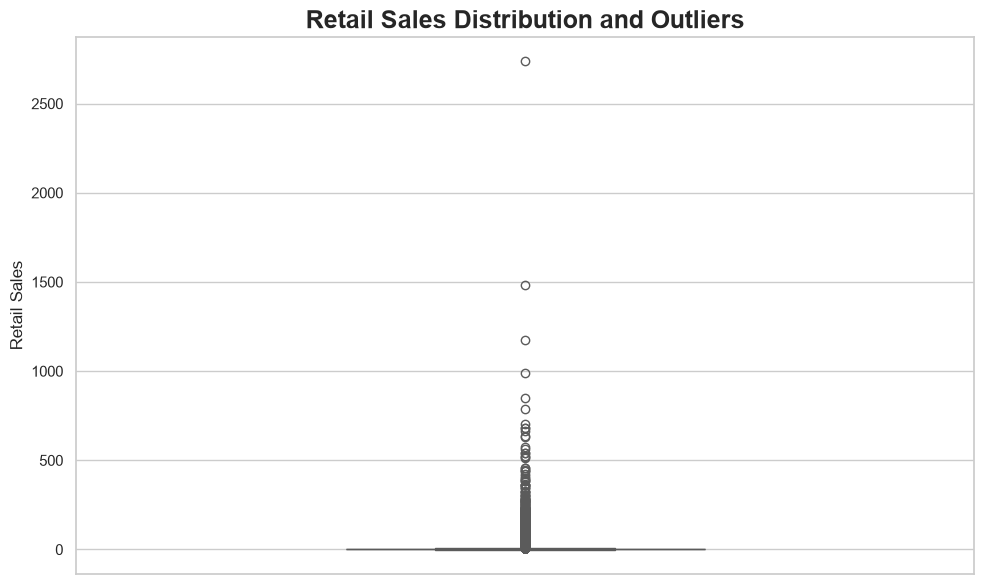

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    y="RETAIL SALES",
    color="#38BDF8",
    width=0.4
)

plt.title(
    "Retail Sales Distribution and Outliers",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Retail Sales", fontsize=12)

plt.tight_layout()

plt.savefig(
    "retail_sales_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()